In [1]:
!pip install arch yfinance pmdarima scipy statsmodels scikit-learn --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.9 MB/s eta 0:00:00


──────────────────────────────────────────────────
ADF Test  →  Log_Return
  ADF statistic : -12.4545
  p-value       : 0.000000
  # lags used   : 8
  Critical (1%) : -3.4344
  Critical (5%) : -2.8633
  Critical (10%) : -2.5677
  → Stationary ✓
──────────────────────────────────────────────────
                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 1609
Model:               SARIMAX(2, 0, 0)   Log Likelihood                4745.976
Date:                Fri, 12 Jun 2026   AIC                          -9485.951
Time:                        13:43:31   BIC                          -9469.801
Sample:                             0   HQIC                         -9479.956
                               - 1609                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      

/tmp/ipykernel_8437/2551583868.py:167: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  fit   = egarch_model.fit(first_obs=first, last_obs=i + end_loc, disp="off")
/tmp/ipykernel_8437/2551583868.py:167: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  fit   = egarch_model.fit(first_obs=first, last_obs=i + end_loc, disp="off")
/tmp/ipykernel_8437/2551583868.py:167: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  fit   = egarch_model.fit(first_obs=first, last_obs=i + end_loc, disp="off")
/tmp/ipykernel_8437/2551583868.py:167: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  fit   = egarch_model.fit(first_obs=f


t-distribution quantiles [99%, 95%]: [1.8171958  0.80681421]

Rolling EGARCH VaR:
             VaR 1%        VaR 5%
count  5.020000e+02  5.020000e+02
mean  -2.409950e+07 -1.166503e+07
std    4.398141e+08  1.983832e+08
min   -9.775957e+09 -4.343403e+09
25%   -2.285021e-02 -1.036240e-02
50%   -1.650409e-02 -7.690361e-03
75%   -1.325517e-02 -6.277986e-03
max    4.021273e+06  4.025343e+06


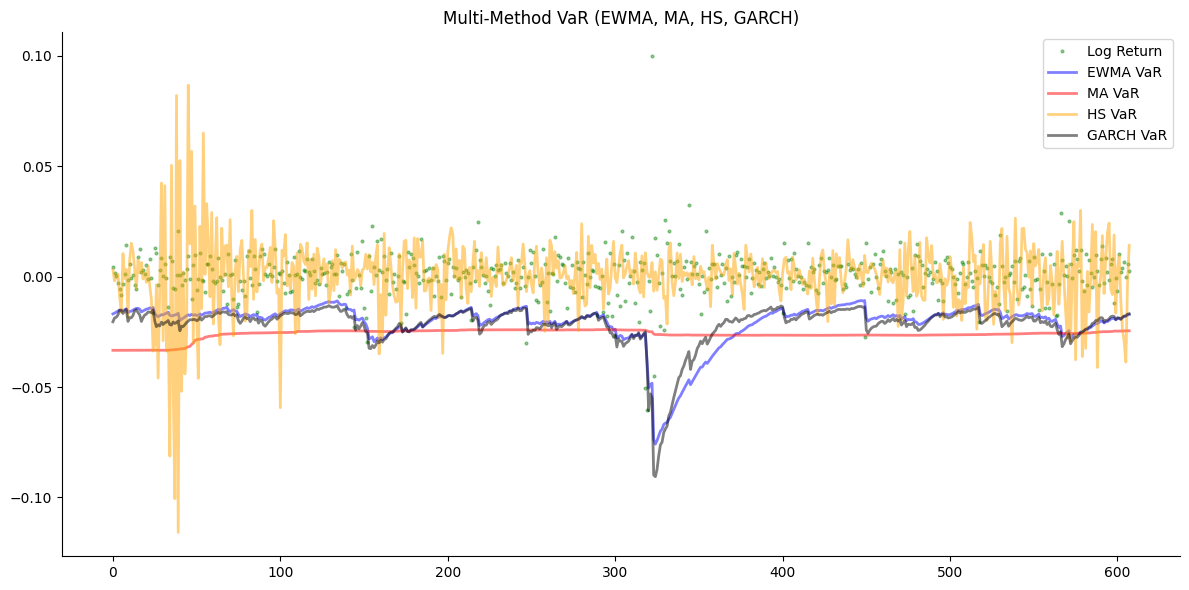


  EGARCH-rolling  |  VaR 99%  (α = 0.01)
  Observations     : 501
  Exceptions       : 23  (expected ≈ 5.0)
  Observed rate    : 0.0459  (nominal 0.01)
  ── Kupiec POF ──────────────────────────
  LR_POF           : 34.7872
  p-value          : 0.0  X REJECT
  ── Christoffersen IND ─────────────────
  LR_IND           : 0.8433
  p-value          : 0.3584  ✓ pass
  ── Combined CC ────────────────────
  LR_CC            : 35.6305
  p-value          : 0.0000  X REJECT

  EGARCH-expanding  |  VaR 99%  (α = 0.01)
  Observations     : 501
  Exceptions       : 73  (expected ≈ 5.0)
  Observed rate    : 0.1457  (nominal 0.01)
  ── Kupiec POF ──────────────────────────
  LR_POF           : 264.9352
  p-value          : 0.0  X REJECT
  ── Christoffersen IND ─────────────────
  LR_IND           : 0.0565
  p-value          : 0.8121  ✓ pass
  ── Combined CC ────────────────────
  LR_CC            : 264.9917
  p-value          : 0.0000  X REJECT

  EGARCH-rolling  |  VaR 95%  (α = 0.05)
  Observatio

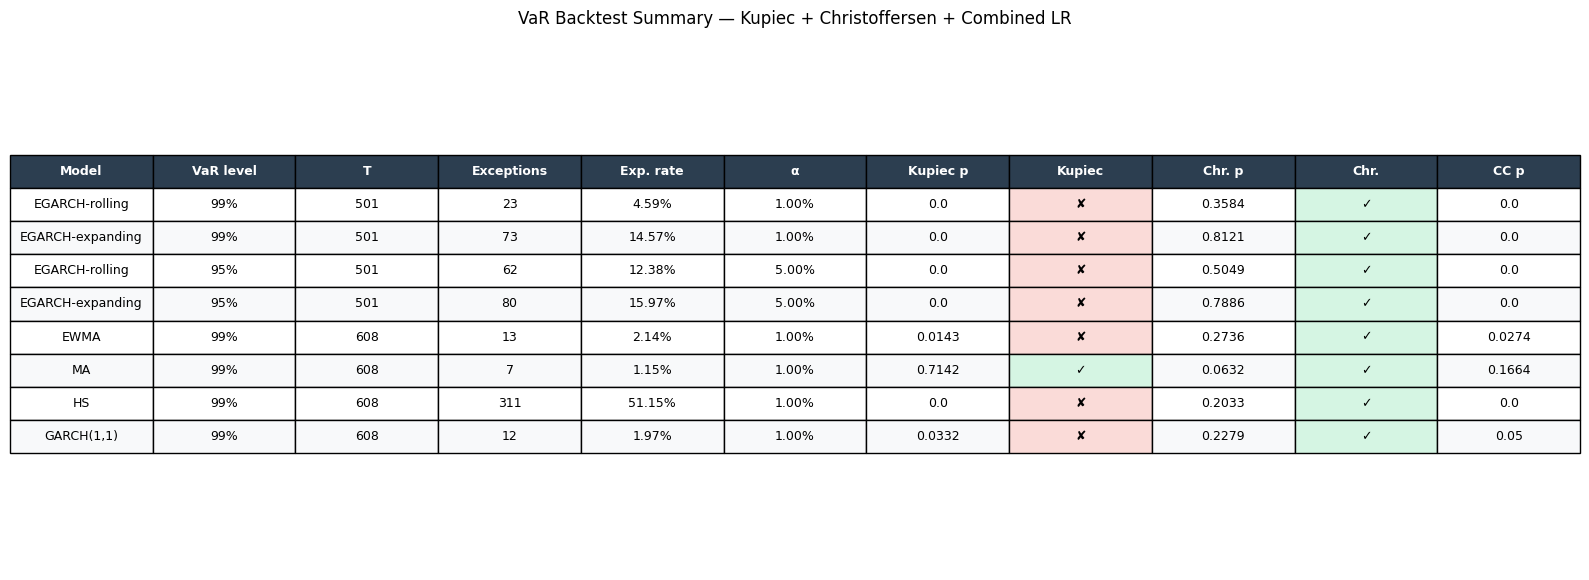


── Expected Shortfall (CVaR) ──
  EGARCH-rolling ES 99% : -0.015668  (return units)
  EGARCH-rolling ES 95% : -0.013233  (return units)
  EWMA          ES 99% : 0.027132  (return units)
  MA            ES 99% : 0.038554  (return units)
  HS            ES 99% : 0.003205  (return units)
  GARCH(1,1)    ES 99% : 0.028216  (return units)


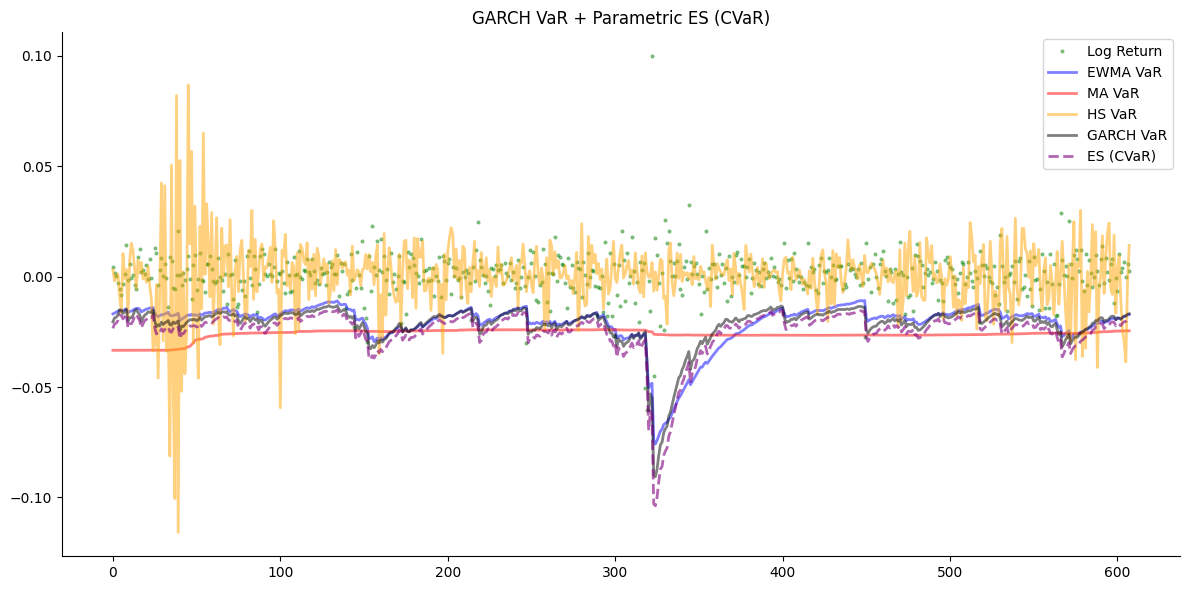

In [5]:
import warnings
import logging
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import yfinance as yf
from scipy import stats
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger(__name__)

rcParams["figure.figsize"] = (12, 5)
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False


# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class Config:
    """Single source of truth for every modelling parameter."""
    tickers:    List[str] = field(default_factory=lambda: ["SPY"])
    start_date: str       = "2020-01-01"
    end_date:   str       = "2026-06-01"
    primary:    str       = "SPY"

    # EGARCH forecast windows
    oos_start:  str       = "2024-01-01"   # OOS start date for EGARCH forecasts
    oos_end:    str       = "2026-01-01"   # OOS end date for EGARCH forecasts

    # Multi-method VaR
    rolling_window: int   = 1000           # WE in original code
    var_p:      float     = 0.01           # left-tail probability (1% VaR)

    # EWMA
    ewma_lambda: float    = 0.94

    # Convergence — v1 bug fix: was 1e03
    fit_tol: float        = 1e-6


CFG = Config()


# ─────────────────────────────────────────────────────────────────────────────
# 2. DATA
# ─────────────────────────────────────────────────────────────────────────────

def download_data(cfg: Config) -> pd.DataFrame:
    """Download adjusted prices, compute log-returns."""
    log.info("Downloading %s  (%s → %s)", cfg.primary, cfg.start_date, cfg.end_date)
    df = yf.download(cfg.primary, start=cfg.start_date, end=cfg.end_date,
                     progress=False, auto_adjust=True)
    df["Log_Return"] = np.log(df["Close"]).diff()
    df.dropna(inplace=True)
    log.info("Downloaded %d observations.", len(df))
    return df


# ─────────────────────────────────────────────────────────────────────────────
# 3. STATISTICAL TESTS
# ─────────────────────────────────────────────────────────────────────────────

def adf_test(series: pd.Series, verbose: bool = True) -> dict:
    """
    ADF unit root test.
    """
    result = adfuller(series.dropna(), autolag="AIC")
    out = {
        "adf_stat":        result[0],
        "p_value":         result[1],   # correct
        "n_lags":          result[2],   # v1 had result[1] here (wrong)
        "n_obs":           result[3],
        "critical_values": result[4],
    }
    if verbose:
        print("─" * 50)
        print(f"ADF Test  →  {series.name}")
        print(f"  ADF statistic : {out['adf_stat']:.4f}")
        print(f"  p-value       : {out['p_value']:.6f}")
        print(f"  # lags used   : {out['n_lags']}")
        for k, v in out["critical_values"].items():
            print(f"  Critical ({k}) : {v:.4f}")
        label = "Stationary ✓" if out["p_value"] < 0.05 else "Non-stationary ✘"
        print(f"  → {label}")
        print("─" * 50)
    return out


# ─────────────────────────────────────────────────────────────────────────────
# 4. ARMA + VOLATILITY MODELS
# ─────────────────────────────────────────────────────────────────────────────

def fit_arma(series: pd.Series, max_p: int = 5, max_q: int = 5):
    """Auto-select ARMA(p,d,q) via AIC."""
    auto = pm.auto_arima(
        series.dropna(), d=0,
        start_p=1, start_q=1, max_p=max_p, max_q=max_q,
        seasonal=False, information_criterion="aic",
        error_action="ignore", stepwise=True, trace=False,
    )
    log.info("Selected %s", auto.order)
    return sm.tsa.SARIMAX(endog=series.dropna(), order=auto.order).fit(disp=False)


def fit_volatility_models(resid: pd.Series, fit_tol: float = 1e-6) -> dict:
    """Fit GARCH-N, GJR-GARCH-t, EGARCH-skewt on ARMA residuals."""
    specs = {
        "GARCH(1,1)-N":   arch_model(resid, p=1, q=1,      mean="Zero", vol="GARCH",  dist="normal"),
        "GJR-GARCH-t":    arch_model(resid, p=1, q=1, o=1,  mean="Zero", vol="GARCH",  dist="t"),
        "EGARCH-skewt":   arch_model(resid, p=1, q=1, o=1,  mean="Zero", vol="EGARCH", dist="skewt"),
    }
    results = {}
    for name, spec in specs.items():
        results[name] = spec.fit(disp="off", options={"ftol": fit_tol})
    return results


# ─────────────────────────────────────────────────────────────────────────────
# 5. EGARCH ROLLING + EXPANDING FORECAST
#
# ─────────────────────────────────────────────────────────────────────────────

def forecast_egarch(
    sp_data: pd.DataFrame,
    cfg: Config,
    expanding: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Rolling (or expanding) window 1-step-ahead EGARCH(1,1,1)-t forecast.

    Returns (mean_df, variance_df), both in LOG-RETURN units.
    """
    egarch_model = arch_model(
        sp_data["Log_Return"], p=1, q=1, o=1, vol="EGARCH", dist="t"
    )

    index   = sp_data.index
    end_loc = np.where(index >= cfg.oos_start)[0].min()
    oos_len = len(sp_data[cfg.oos_start : cfg.oos_end])
    start_loc = 0

    forecasts_mean = {}
    forecasts_var  = {}

    for i in range(oos_len):
        first = start_loc if expanding else start_loc + i
        fit   = egarch_model.fit(first_obs=first, last_obs=i + end_loc, disp="off")

        fc_mean = fit.forecast(horizon=1).mean
        fc_var  = fit.forecast(horizon=1).variance

        # Original indexing: .iloc[i + end_loc - 1]
        # FIX: For horizon=1, the forecast output has only one element at integer position 0
        m = fc_mean.iloc[0]
        v = fc_var.iloc[0]
        forecasts_mean[m.name] = m
        forecasts_var[v.name]  = v

        if i % 50 == 0:
            label = "Expanding" if expanding else "Rolling"
            log.info("%s forecast: %d / %d", label, i, oos_len)

    mean_df = pd.DataFrame(forecasts_mean).T
    var_df  = pd.DataFrame(forecasts_var).T
    return mean_df, var_df


def compute_egarch_var(
    mean_df: pd.DataFrame,
    var_df:  pd.DataFrame,
    q: np.ndarray,
) -> pd.DataFrame:
    """
    VaR from EGARCH forecasts. Matches original cell 52 exactly:
        VaR = -mean - sqrt(variance) * q

    q comes from egarch_model.distribution.ppf([0.99, 0.95], nu).
    These are POSITIVE numbers (right-tail quantiles of t-dist).
    Result is NEGATIVE (same sign as loss returns).
    """
    var_vals = -mean_df.values - np.sqrt(var_df).values * q[None, :]
    return pd.DataFrame(
        var_vals,
        columns=["VaR 1%", "VaR 5%"],
        index=var_df.index,
    )


# ─────────────────────────────────────────────────────────────────────────────
# 6. MULTI-METHOD VAR  (EWMA | MA | HS | GARCH)
#    Matches original cells 57-58 exactly
# ─────────────────────────────────────────────────────────────────────────────

def compute_multi_method_var(
    sp_data: pd.DataFrame,
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Four-method rolling VaR, identical to original cells 57-58.
    Returns are raw log-returns (np.diff(np.log(Close))).
    VaR stored as POSITIVE values (loss magnitude), value=1.

    Returns (y, VaR) where:
        y   = log-returns array
        VaR = (T, 4) array: [EWMA, MA, HS, GARCH]
    """
    y  = np.diff(np.log(sp_data["Close"]), n=1, axis=0)
    T  = len(y)
    WE = cfg.rolling_window
    p  = cfg.var_p
    l1 = int(WE * p)
    value = 1                                      # VaR in return units

    VaR = np.full([T, 4], np.nan)

    # EWMA warm-up
    lmbda = cfg.ewma_lambda
    s11   = np.var(y[1:30])
    for t in range(1, WE):
        s11 = lmbda * s11 + (1 - lmbda) * y[t - 1] ** 2

    for t in range(WE, T):
        t1     = t - WE
        t2     = t - 1
        window = y[t1 : t2 + 1]

        s11 = lmbda * s11 + (1 - lmbda) * y[t - 1] ** 2

        # 0: EWMA
        VaR[t, 0] = -stats.norm.ppf(p) * np.sqrt(s11) * value

        # 1: MA
        VaR[t, 1] = -np.std(window, ddof=1) * stats.norm.ppf(p) * value

        # 2: HS
        ys = np.sort(window)
        VaR[t, 2] = -ys[l1 - 1] * value

        # 3: GARCH(1,1)
        try:
            am  = arch_model(window, mean="Zero", vol="Garch",
                             p=1, o=0, q=1, dist="Normal")
            res = am.fit(update_freq=0, disp="off", show_warning=False)
            par = [res.params[0], res.params[1], res.params[2]]
            s4  = (par[0]
                   + par[1] * window[WE - 1] ** 2
                   + par[2] * res.conditional_volatility[-1] ** 2)
            VaR[t, 3] = -np.sqrt(s4) * stats.norm.ppf(p) * value
        except Exception:
            VaR[t, 3] = VaR[t, 1]                 # fallback to MA

        if t % 200 == 0:
            log.info("Multi-method VaR: %d / %d", t, T)

    return y, VaR


# ─────────────────────────────────────────────────────────────────────────────
# 7. BACKTESTING — Kupiec + Christoffersen + Combined LR
# ─────────────────────────────────────────────────────────────────────────────

def _count_exceptions_egarch(
    returns_oos: pd.Series,
    var_series: pd.Series,
) -> pd.Series:
    """
    Exception indicator for EGARCH VaR.
    EGARCH VaR is NEGATIVE (same sign as losses).
    Exception: return < VaR  (return dropped below the threshold).
    """
    aligned = pd.concat([returns_oos, var_series], axis=1).dropna()
    aligned.columns = ["ret", "var"]
    return (aligned["ret"] < aligned["var"]).astype(int)


def _count_exceptions_multi(
    y: np.ndarray,
    VaR: np.ndarray,
    WE: int,
    col_idx: int,
) -> np.ndarray:
    """
    Exception indicator for multi-method VaR.
    Multi-method VaR is POSITIVE (loss magnitude), plotted as -VaR.
    Exception: return < -VaR  (i.e. loss exceeds VaR magnitude).
    Equivalently: -return > VaR.
    """
    exceptions = np.zeros(len(y), dtype=int)
    for t in range(WE, len(y)):
        if not np.isnan(VaR[t, col_idx]):
            if y[t] < -VaR[t, col_idx]:           # loss exceeds VaR
                exceptions[t] = 1
    return exceptions[WE:]


def kupiec_pof(exceptions: np.ndarray, alpha: float) -> dict:
    """
    Kupiec (1995) Proportion Of Failures test.
    H0: observed exception rate = alpha.
    """
    T = len(exceptions)
    V = int(np.sum(exceptions))
    p_hat = V / T if T > 0 else 0.0

    if p_hat == 0 or p_hat == 1:
        return {"T": T, "V": V, "p_hat": p_hat, "alpha": alpha,
                "lr": np.nan, "p_value": np.nan, "reject": False}

    lr = -2 * (V * np.log(alpha / p_hat) + (T - V) * np.log((1 - alpha) / (1 - p_hat)))
    p_val = 1 - stats.chi2.cdf(lr, df=1)
    return {"T": T, "V": V, "p_hat": round(p_hat, 4), "alpha": alpha,
            "lr": round(lr, 4), "p_value": round(p_val, 4),
            "reject": p_val < 0.05}


def christoffersen_ind(exceptions: np.ndarray) -> dict:
    """
    Christoffersen (1998) independence test.
    H0: exceptions are serially independent (not clustered).
    """
    exc = exceptions.astype(int)
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(exc)):
        pr, cu = exc[i - 1], exc[i]
        if   pr == 0 and cu == 0: n00 += 1
        elif pr == 0 and cu == 1: n01 += 1
        elif pr == 1 and cu == 0: n10 += 1
        else:                      n11 += 1

    p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    p   = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    sl = lambda x: np.log(x) if x > 0 else 0.0
    lr_ind = -2 * (
        (n00 + n10) * sl(1 - p)     + (n01 + n11) * sl(p)
        - n00 * sl(1 - p01)         - n01 * sl(max(p01, 1e-10))
        - n10 * sl(1 - p11)         - n11 * sl(max(p11, 1e-10))
    )
    p_val = 1 - stats.chi2.cdf(lr_ind, df=1)
    return {"n00": n00, "n01": n01, "n10": n10, "n11": n11,
            "lr": round(lr_ind, 4), "p_value": round(p_val, 4),
            "reject": p_val < 0.05}


def backtest_single(
    exceptions: np.ndarray,
    alpha: float,
    model_name: str,
) -> dict:
    """Run Kupiec + Christoffersen + combined LR. Print and return."""
    pof = kupiec_pof(exceptions, alpha)
    ind = christoffersen_ind(exceptions)

    lr_cc = np.nan
    p_cc  = np.nan
    if not np.isnan(pof["lr"]) and not np.isnan(ind["lr"]):
        lr_cc = pof["lr"] + ind["lr"]
        p_cc  = 1 - stats.chi2.cdf(lr_cc, df=2)

    pct = int((1 - alpha) * 100)
    print(f"\n{'='*60}")
    print(f"  {model_name}  |  VaR {pct}%  (α = {alpha})")
    print(f"{'='*60}")
    print(f"  Observations     : {pof['T']}")
    print(f"  Exceptions       : {pof['V']}  (expected ≈ {alpha * pof['T']:.1f})")
    print(f"  Observed rate    : {pof['p_hat']:.4f}  (nominal {alpha})")
    print(f"  ── Kupiec POF ──────────────────────────")
    print(f"  LR_POF           : {pof['lr']}")
    print(f"  p-value          : {pof['p_value']}  "
          f"{'X REJECT' if pof['reject'] else '✓ pass'}")
    print(f"  ── Christoffersen IND ─────────────────")
    print(f"  LR_IND           : {ind['lr']}")
    print(f"  p-value          : {ind['p_value']}  "
          f"{'X REJECT' if ind['reject'] else '✓ pass'}")
    print(f"  ── Combined CC ────────────────────")
    if not np.isnan(lr_cc):
        print(f"  LR_CC            : {lr_cc:.4f}")
        print(f"  p-value          : {p_cc:.4f}  "
              f"{'X REJECT' if p_cc < 0.05 else '✓ pass'}")
    else:
        print(f"  (not enough exceptions to compute)")
    print(f"{'='*60}")

    return {
        "model": model_name, "alpha": alpha,
        "kupiec": pof, "christoffersen": ind,
        "lr_cc": lr_cc, "p_cc": p_cc,
    }


def backtest_summary_table(results: list) -> pd.DataFrame:
    """Tidy summary DataFrame of all backtest results."""
    rows = []
    for r in results:
        pof, ind = r["kupiec"], r["christoffersen"]
        rows.append({
            "Model":        r["model"],
            "VaR level":    f"{int((1-r['alpha'])*100)}%",
            "T":            pof["T"],
            "Exceptions":   pof["V"],
            "Exp. rate":    f"{pof['p_hat']:.2%}" if isinstance(pof["p_hat"], float) else pof["p_hat"],
            "α":            f"{r['alpha']:.2%}",
            "Kupiec p":     pof["p_value"],
            "Kupiec":       "✓" if not pof["reject"] else "✘",
            "Chr. p":       ind["p_value"],
            "Chr.":         "✓" if not ind["reject"] else "✘",
            "CC p":         round(r["p_cc"], 4) if not np.isnan(r["p_cc"]) else "—",
        })
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────────────────────────────────────
# 8. EXPECTED SHORTFALL (CVaR)
# ─────────────────────────────────────────────────────────────────────────────

def compute_es_egarch(
    returns_oos: pd.Series,
    var_series: pd.Series,
) -> float:
    """
    Empirical ES for EGARCH VaR.
    ES = mean of returns that fell below VaR threshold.
    All values in RETURN UNITS.
    """
    aligned = pd.concat([returns_oos, var_series], axis=1).dropna()
    aligned.columns = ["ret", "var"]
    tail = aligned["ret"][aligned["ret"] < aligned["var"]]
    return tail.mean() if len(tail) > 0 else np.nan


def compute_es_multi(
    y: np.ndarray,
    VaR: np.ndarray,
    WE: int,
    col_idx: int,
) -> float:
    """
    Empirical ES for multi-method VaR.
    VaR is POSITIVE, exception when y < -VaR.
    ES = mean(-y) for those days = average loss magnitude in exceptions.
    Returns POSITIVE number (average loss in return units).
    """
    losses = []
    for t in range(WE, len(y)):
        if not np.isnan(VaR[t, col_idx]):
            if y[t] < -VaR[t, col_idx]:
                losses.append(-y[t])
    return np.mean(losses) if losses else np.nan


def compute_parametric_es_multi(
    VaR: np.ndarray,
    WE: int,
    col_idx: int,
    alpha: float,
) -> np.ndarray:
    """
    Parametric ES under normal assumption:
       ES = sigma * phi(z_alpha) / alpha
    For multi-method VaR:  VaR = sigma * |z_alpha|
    So: ES = VaR * phi(z_alpha) / (alpha * |z_alpha|)
    Returns array of ES values (POSITIVE, same convention as VaR).
    """
    z = stats.norm.ppf(alpha)
    ratio = stats.norm.pdf(z) / (alpha * abs(z))
    ES = np.full_like(VaR[:, col_idx], np.nan)
    for t in range(WE, len(VaR)):
        if not np.isnan(VaR[t, col_idx]):
            ES[t] = VaR[t, col_idx] * ratio
    return ES


# ─────────────────────────────────────────────────────────────────────────────
# 9. EVALUATION METRICS
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_forecast(obs: pd.Series, pred: pd.Series, label: str = "") -> dict:
    """MAE, RMSE, MAPE (safe: masks near-zero obs to avoid inf)."""
    aligned = pd.concat([obs, pred], axis=1).dropna()
    o, p = aligned.iloc[:, 0].values, aligned.iloc[:, 1].values
    mae  = mean_absolute_error(o, p)
    rmse = np.sqrt(mean_squared_error(o, p))
    nz   = np.abs(o) > 1e-10
    mape = np.mean(np.abs((o[nz] - p[nz]) / o[nz])) * 100 if nz.sum() > 0 else np.nan
    if label:
        print(f"── {label}")
        print(f"   MAE  : {mae:.6f}")
        print(f"   RMSE : {rmse:.6f}")
        print(f"   MAPE : {mape:.2f}%" if not np.isnan(mape) else "   MAPE : N/A")
    return {"mae": mae, "rmse": rmse, "mape": mape}


# ─────────────────────────────────────────────────────────────────────────────
# 10. PLOTS
# ─────────────────────────────────────────────────────────────────────────────

def plot_egarch_var(
    sp_data: pd.DataFrame,
    var_roll: pd.DataFrame,
    var_exp: Optional[pd.DataFrame] = None,
    cfg: Config = CFG,
    title: str = "EGARCH VaR Forecast",
) -> None:
    """Plot EGARCH VaR vs returns (original style from cells 53-54)."""
    plt.figure(figsize=(12, 6))
    ret_oos = sp_data["Log_Return"][cfg.oos_start : cfg.oos_end]
    plt.plot(ret_oos, "og", markersize=3, alpha=0.6, label="Log Return")
    plt.plot(var_roll["VaR 1%"], color="red",  alpha=0.6, lw=2, label="Rolling VaR 1%")
    plt.plot(var_roll["VaR 5%"], color="blue", alpha=0.6, lw=2, label="Rolling VaR 5%")
    if var_exp is not None:
        plt.plot(var_exp["VaR 1%"], color="orange", alpha=0.6, lw=2,
                 ls="--", label="Expanding VaR 1%")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_multi_var(
    y: np.ndarray,
    VaR: np.ndarray,
    WE: int,
    ES: Optional[np.ndarray] = None,
    title: str = "Multi-Method VaR & ES",
) -> None:
    """Plot multi-method VaR vs returns (original style from cell 59)."""
    T = len(y)
    plt.figure(figsize=(12, 6))
    plt.plot(y[WE:T], "og", markersize=2, alpha=0.4, label="Log Return")
    plt.plot(-VaR[WE:T, 0], color="blue",   alpha=0.5, lw=2, label="EWMA VaR")
    plt.plot(-VaR[WE:T, 1], color="red",    alpha=0.5, lw=2, label="MA VaR")
    plt.plot(-VaR[WE:T, 2], color="orange", alpha=0.5, lw=2, label="HS VaR")
    plt.plot(-VaR[WE:T, 3], color="black",  alpha=0.5, lw=2, label="GARCH VaR")
    if ES is not None:
        plt.plot(-ES[WE:T],    color="purple", alpha=0.6, lw=2, ls="--", label="ES (CVaR)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_backtest_table(summary_df: pd.DataFrame) -> None:
    """Render backtest summary as a styled matplotlib table."""
    fig, ax = plt.subplots(figsize=(16, len(summary_df) * 0.55 + 1.5))
    ax.axis("off")
    tbl = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                   cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.7)
    for j in range(len(summary_df.columns)):
        tbl[0, j].set_facecolor("#2c3e50")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(summary_df) + 1):
        for j in range(len(summary_df.columns)):
            val = str(summary_df.iloc[i - 1, j])
            color = ("#fadbd8" if val == "✘" else
                     "#d5f5e3" if val == "✓" else
                     "#f8f9fa" if i % 2 == 0 else "white")
            tbl[i, j].set_facecolor(color)
    ax.set_title("VaR Backtest Summary — Kupiec + Christoffersen + Combined LR",
                 fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 11. ORCHESTRATOR
# ─────────────────────────────────────────────────────────────────────────────

def run_pipeline(cfg: Config = CFG) -> dict:
    """
    Full pipeline preserving original logic, adding backtesting + ES.

    Sections:
      1. Data download
      2. ADF test (bug-fixed)
      3. ARMA + volatility models
      4. EGARCH rolling/expanding forecasts + VaR
      5. Multi-method VaR (EWMA, MA, HS, GARCH)
      6. Backtesting (Kupiec + Christoffersen)
      7. Expected Shortfall
      8. Summary
    """
    # ── 1. Data ─────────────────────────────────────
    sp_data = download_data(cfg)

    # ── 2. ADF ─────────────────────────────────────
    adf_test(sp_data["Log_Return"])

    # ── 3. ARMA + Vol models ───────────────────────────────
    arma_fit = fit_arma(sp_data["Log_Return"])
    print(arma_fit.summary())

    vol_models = fit_volatility_models(arma_fit.resid, cfg.fit_tol)
    for name, res in vol_models.items():
        print(f"\n── {name}")
        print(res.summary())

    # ── 4. EGARCH forecasts ─────────────────────────────────
    log.info("EGARCH rolling window forecast …")
    mean_roll, var_roll = forecast_egarch(sp_data, cfg, expanding=False)

    log.info("EGARCH expanding window forecast …")
    mean_exp, var_exp = forecast_egarch(sp_data, cfg, expanding=True)

    # Get distribution quantiles (POSITIVE, right-tail)
    egarch_model = arch_model(
        sp_data["Log_Return"], p=1, q=1, o=1, vol="EGARCH", dist="t"
    )
    egarch_fit = egarch_model.fit(disp="off", last_obs=cfg.oos_start)
    q = egarch_model.distribution.ppf([0.99, 0.95], egarch_fit.params[-1])
    print(f"\nt-distribution quantiles [99%, 95%]: {q}")

    # VaR in return units (NEGATIVE = loss threshold)
    var_egarch_roll = compute_egarch_var(mean_roll, var_roll, q)
    var_egarch_exp  = compute_egarch_var(mean_exp, var_exp, q)
    print("\nRolling EGARCH VaR:")
    print(var_egarch_roll.describe())

    #plot_egarch_var(sp_data, var_egarch_roll, var_egarch_exp, cfg)

    # ── 5. Multi-method VaR ───────────────────────────────
    log.info("Multi-method VaR (WE=%d) …", cfg.rolling_window)
    y, VaR = compute_multi_method_var(sp_data, cfg)

    plot_multi_var(y, VaR, cfg.rolling_window,
                   title="Multi-Method VaR (EWMA, MA, HS, GARCH)")

    # ── 6. Backtesting ─────────────────────────────────
    backtest_results = []
    ret_oos = sp_data["Log_Return"][cfg.oos_start : cfg.oos_end]

    # EGARCH backtests (at 1% and 5%)
    for col, alpha in [("VaR 1%", 0.01), ("VaR 5%", 0.05)]:
        # Rolling
        exc_r = _count_exceptions_egarch(ret_oos, var_egarch_roll[col])
        backtest_results.append(
            backtest_single(exc_r.values, alpha, f"EGARCH-rolling")
        )
        # Expanding
        exc_e = _count_exceptions_egarch(ret_oos, var_egarch_exp[col])
        backtest_results.append(
            backtest_single(exc_e.values, alpha, f"EGARCH-expanding")
        )

    # Multi-method backtests (at 1%)
    method_names = ["EWMA", "MA", "HS", "GARCH(1,1)"]
    for col_idx, name in enumerate(method_names):
        exc_m = _count_exceptions_multi(y, VaR, cfg.rolling_window, col_idx)
        backtest_results.append(
            backtest_single(exc_m, cfg.var_p, name)
        )

    summary = backtest_summary_table(backtest_results)
    print("\n" + summary.to_string(index=False))
    plot_backtest_table(summary)

    # ── 7. Expected Shortfall ─────────────────────────────────
    print("\n── Expected Shortfall (CVaR) ──")
    for col, alpha in [("VaR 1%", 0.01), ("VaR 5%", 0.05)]:
        es_val = compute_es_egarch(ret_oos, var_egarch_roll[col])
        pct = int((1 - alpha) * 100)
        print(f"  EGARCH-rolling ES {pct}% : {es_val:.6f}  (return units)")

    for col_idx, name in enumerate(method_names):
        es_val = compute_es_multi(y, VaR, cfg.rolling_window, col_idx)
        print(f"  {name:12s}  ES 99% : {es_val:.6f}  (return units)")

    # Parametric ES for GARCH method
    ES_garch = compute_parametric_es_multi(VaR, cfg.rolling_window, 3, cfg.var_p)
    plot_multi_var(y, VaR, cfg.rolling_window, ES=ES_garch,
                   title="GARCH VaR + Parametric ES (CVaR)")

    return {
        "sp_data": sp_data,
        "arma": arma_fit, "vol_models": vol_models,
        "var_egarch_roll": var_egarch_roll, "var_egarch_exp": var_egarch_exp,
        "y": y, "VaR_multi": VaR,
        "backtest_results": backtest_results, "summary": summary,
    }


if __name__ == "__main__":
    results = run_pipeline(CFG)
